In [20]:
import numpy
import matplotlib.pyplot as plt
from pandas import read_csv
from pathlib import Path

In [21]:
file = 'EXAMPLE_batchCFD_3_el_wing' / Path('results.csv')



def find_repo_root(marker='01_Input_Files'):
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / marker).is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find the repo root (looked for a '{marker}' folder above {start})")

REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / '05_CFD_Results'
csv_path = RESULTS_DIR / file
if not csv_path.is_file():
    available = sorted(p.relative_to(RESULTS_DIR) for p in RESULTS_DIR.rglob('*.csv'))
    raise FileNotFoundError(
        f"CSV not found: {csv_path}\nAvailable result CSVs:\n" + "\n".join(f"  {p}" for p in available)
    )
data = read_csv(csv_path)
data['L/D'] = data['Cl'] / data['Cd']

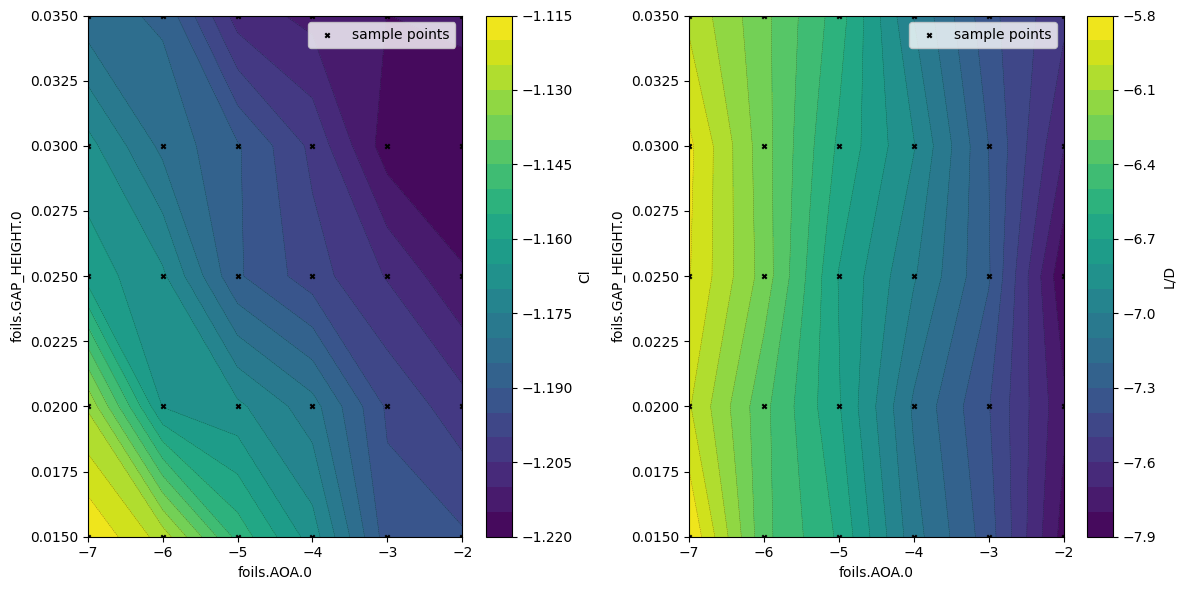

In [22]:
# Cl contour over the two swept parameters (auto-detected: any results.csv
# column that isn't one of the fixed result/bookkeeping columns).
FIXED_COLS = {'index', 'status', 'Cl', 'Cd', 'lift', 'drag', 'mesh', 'error', 'L/D'}
sweep_cols = [c for c in data.columns if c not in FIXED_COLS]
if len(sweep_cols) != 2:
    raise ValueError(
        f"Expected exactly 2 swept parameters for a contour plot, found {len(sweep_cols)}: {sweep_cols}"
    )
x_col, y_col = sweep_cols

ok_data = data[data['status'] == 'ok']

grid = ok_data.pivot_table(index=y_col, columns=x_col, values='L/D')
X, Y = numpy.meshgrid(grid.columns.values, grid.index.values)
Z = grid.values

fig, ax = plt.subplots(1,2,figsize=(12, 6))

contour = ax[1].contourf(X, Y, Z, levels=20, cmap='viridis')
ax[1].contour(X, Y, Z, levels=20, colors='k', linewidths=0.3, alpha=0.5)
ax[1].scatter(ok_data[x_col], ok_data[y_col], c='k', s=10, marker='x', label='sample points')

fig.colorbar(contour, ax=ax[1], label='L/D')
ax[1].set_xlabel(x_col)
ax[1].set_ylabel(y_col)
ax[1].legend()

grid = ok_data.pivot_table(index=y_col, columns=x_col, values='Cl')
X, Y = numpy.meshgrid(grid.columns.values, grid.index.values)
Z = grid.values

contour = ax[0].contourf(X, Y, Z, levels=20, cmap='viridis')
ax[0].contour(X, Y, Z, levels=20, colors='k', linewidths=0.3, alpha=0.5)
ax[0].scatter(ok_data[x_col], ok_data[y_col], c='k', s=10, marker='x', label='sample points')

fig.colorbar(contour, ax=ax[0], label='Cl')
ax[0].set_xlabel(x_col)
ax[0].set_ylabel(y_col)
ax[0].legend()

fig.tight_layout()
plt.show()